# [1교시]

### 전이학습(word2vec, Glove, FastText)
- word2vec
    - 주변단어를 통해 중심단어를 예측, 중심단어를 통해서 주변 단어를 예측 단어 벡터화
- Glove
    - 카운트 기반과 예측기반의 장점을 결합해서 단어의 동시등장 행렬을 분해
- FastText
    - 단어를 subword(n-gram) 단위로 쪼개서 oov(out-of-vocabulary)문제 해결

2. 정적 임베딩한계정 : 문맥 미반영(한 단어가 문맥에서 항상 동일한 벡터)
    - 동음이의어 처리 불가: 배를 먹다, 배를 타다, 배가 아프다에서 배는 모든 같은 벡터공간에 매핑

In [1]:
# 간단한 코퍼스를 활용 Word2Vec 학습, 단어간 유사도 확인
# !pip install gensim
from gensim.models import Word2Vec

In [2]:
# 토큰화된 문장
sentences = [
    ['I', 'love', 'natural', 'language', 'processing'],
    ['natural', 'language', 'processing', 'is', 'fun'],
    ['I', 'enjoy', 'learning', 'machine', 'learning']
]
# Word2Vec모델 학습(CBOW 기반)
w2v_model = Word2Vec(sentences,vector_size=10,window=2, min_count=1,epochs=10000)
print(f"language 벡터 : {w2v_model.wv['language']}")
print(f"natural, language의 유사도 : {w2v_model.wv.similarity('natural','language')}")
print(f"processing, language의 유사도 : {w2v_model.wv.similarity('processing','language')}")

language 벡터 : [ 0.46356866  0.7317976   0.73706156 -0.04372329  0.27976826 -0.24921551
  0.45000407  0.15153548 -1.0181676  -0.53059024]
natural, language의 유사도 : 0.9198233485221863
processing, language의 유사도 : 0.9289067983627319


In [3]:
# 글로벌 동시 등장확률(Co occurence) 정보를 활용 : king - man + woman = queen 벡터연산이 작동하는지 확인
import gensim.downloader as api
print('Glove 모델 다운로드중.... 대략 66MB')
glove_model = api.load('glove-wiki-gigaword-50')
print('로딩완료\n')
print(f"king , queen 유사도 : {glove_model.similarity('king','queen')}")
print(f"man , woman 유사도 : {glove_model.similarity('man','woman')}")

Glove 모델 다운로드중.... 대략 66MB
[==================================================] 100.0% 66.0/66.0MB downloaded
로딩완료

king , queen 유사도 : 0.7839043140411377
man , woman 유사도 : 0.8860337734222412


In [4]:
# 벡터 연산  king-man+woman = queen
result = glove_model.most_similar(positive=['king','woman'], negative=['man'], topn=3)
print(f'king-man+woman 에 가장가까운단어 : {result}')

king-man+woman 에 가장가까운단어 : [('queen', 0.8523604273796082), ('throne', 0.7664334177970886), ('prince', 0.7592144012451172)]


In [6]:
# FastText (OOV 문제 해결)
# 훈련데이터에 없거나 오타자에 대해 유연하게 동작하는지 확인
from gensim.models import FastText
# 실습데이터가 작아서  과적합을 피하기 위해 10000번학습
ft_model = FastText(sentences,vector_size=10,window=2,min_count=1,min_n=3, max_n=6, epochs=10000)
# 학습데이터에 존재하는 단어
print(f"language 벡터 : {ft_model.wv['languate']}")
print(f"학습되지 않은 단어 : languag : {ft_model.wv['languag']}")
print(f"langug, languge의 유사도 : {ft_model.wv.similarity('language', 'languag')}")

language 벡터 : [-0.26260483  0.35754687 -0.26880795  0.29179794  0.3724388   0.12110792
  0.19623452  0.30772692  0.13183883 -0.03056743]
학습되지 않은 단어 : languag : [-0.38566     0.5605096  -0.41307887  0.43644932  0.58965886  0.1577196
  0.2992876   0.47647923  0.20024978 -0.0366558 ]
langug, languge의 유사도 : 0.9998655319213867


In [7]:
# Static 임베딩의 한계점
# 동음의이어 처리 불가능  : 하나의 단어가 문맥에서 전혀 다른 의미로 사용될때 모델이 어떻게 반환하는지 실험
# bank(은행, 강둑)

vector_bank = glove_model['bank']
print(vector_bank.shape)
sim_money = glove_model.similarity('bank','money')
sim_river = glove_model.similarity('bank','river')
print(f'sim_money 유사도 : {sim_money}')
print(f'sim_river 유사도 : {sim_river}')
# 예상결과는 bank에 money하고 river의 의미가 짬봉된 vector 
# --> why 이미 수만은 문장을통해 bank money,  bank river의 관계를 학습

(50,)
sim_money 유사도 : 0.6360428929328918
sim_river 유사도 : 0.4142034649848938


# [2교시]

### ELMO(Embedding from Language Models)
- Bi-LSTM 기반 양방향 언어모델(BiLM) 구조
    - 언어모델 : 이전 단어들을 보고 다음 단어를 예측하는 모델
    - Bi-LSTM(Bidirectional LSTM) : 순방향 LSTM + 역방향 LSTM 결합
    - ELMO : Bi-LSTM을 여러 층 쌓아올려 특정 단어의 의미를 파악할 때 그 단어의 앞 문맥과 뒤 문맥을 동시에 모두 고려

- 문맥에 따라 변화는 Dynamic 임베딩 원리 :
    - 1교시 static 임베딩은 사전에서 단어 찾는거와 유사
    - 임베딩 값이 다르게 생성되어서 동음이의어 문제(Homonym)를 완벽하게 해결
- Feature-based 전이학습(Transfer Learing)
    - 전이학습 : 거대 데이터로 미리 학습된 지식을 가져와서 내 문제에 맞춰 사용하는 기법
    - Feature-based : 기존에 쓰던 모델(사용자의 모델 예를 들어 텍스트 분류기)의 내부 구조를 바꾸지 않음, ELMO가 만들어준 똑똑한 동적 벡터를 단순히 이어붙여(concatenation) 특징(Feature)으로 추가해주는 방식

In [9]:
# Bi-LSTM
import torch
import torch.nn as nn
import torch.nn.functional as F

embed_size = 10
hidden_size = 12
# input_size : 입력되는 단어벡터의 차원
# hiddeen_size : LSTM 내부적으로 사용하는 은닉상태
# num_layers : LSTM을 몇겹으로 쌓는지
# bidirectrinal : True, 정방향과 역방향 두개의 LSTM이 동시에 작동
#       최종 벡터가 두 방향벡터의 결과를 이어붙이므로 hidden_size*2

elmo_bilstm = nn.LSTM(input_size=embed_size,
                      hidden_size=hidden_size, num_layers=2, batch_first=True, bidirectional=True)
# 가상의 데이터 입력(문장 1개, 5개의 단어, 각 단어는 10차원)
dumy_input = torch.rand(1, 5, embed_size)
output, (h_n, c_n) = elmo_bilstm(dumy_input)
print(f'입력 텐서 차원 : {dumy_input.shape}')
print(f'출력 텐서 차원 : {output.shape}')
# 마지막 출력이 24인 이유는 hidden_size : 12 --> 정방향, 역방향 = 24차원

입력 텐서 차원 : torch.Size([1, 5, 10])
출력 텐서 차원 : torch.Size([1, 5, 24])


In [20]:
# bank의 벡터값이 문맥에 따라서 다르게 나오는지 코사인 유사도로 확인
# F.cosine_similarity(텐서1, 텐서2, dim) : dim 에 해당하는 차원을 기준으로 계산   -1 ~ 1
# 임시 단어사전 구성 10차원 정적 임베딩
word_to_idx = {'I':0, 'deposited':1, 'money':2, 'in':3, 'the':4, 'bank':5, 'walked':6, 'by':7, 'river':8, '.':9}
static_embedding = nn.Embedding(num_embeddings=10, embedding_dim=embed_size)

# 문장 A: I deposited money in the bank .
sentence_A_idx = torch.tensor([[word_to_idx[w] for w in ['I', 'deposited', 'money', 'in', 'the', 'bank', '.']]])
# 문장 B: I walked by the river bank .
sentence_B_idx = torch.tensor([[word_to_idx[w] for w in ['I', 'walked', 'by', 'the', 'river', 'bank', '.']]])

# 1. 정적 임베딩 통과(문맥반영안됨)
emb_A = static_embedding(sentence_A_idx)
emb_B = static_embedding(sentence_B_idx)

# 2. Bi-LSTM(양방향 적용된 임베딩)
elmo_out_A,_ = elmo_bilstm(emb_A)
elmo_out_B,_ = elmo_bilstm(emb_B)

# 3. 두 문장에서 bank 단어의 위치 (인덱스) 둘 다 5
# 정적 임베딩에서 bank 벡터간 유사도 (A문장의 Bank vs B문장의 Bank)
static_bank_A = emb_A[0,5, :]
static_bank_B = emb_B[0,5, :]
static_sim = F.cosine_similarity(static_bank_A.unsqueeze(0), static_bank_B.unsqueeze(0))

# ELMo 임베딩에서 bank

elmo_bank_A = elmo_out_A[0,5,:]
elmo_bank_B = elmo_out_B[0,5,:]
elmo_sim = F.cosine_similarity(elmo_bank_A.unsqueeze(0), elmo_bank_B.unsqueeze(0))

# static_bank_A.shape

print(f'정적 임베딩 : {static_sim.item()}')
print(f'정적 임베딩 : {elmo_sim.item()}')


정적 임베딩 : 1.0
정적 임베딩 : 0.9960572719573975


In [21]:
# Feature_based 전이학습
# ELMo가 생성한 문맥을 반영한 벡터를 기존 딥러닝 분류기에 어떻게 전이학습 가져다 쓰는지 (Concat)
# 기존 10차원이고 ELMo 벡터가 24차원이면 둘을 붙이면 총 34차원의 풍부한 특징(Feature) 벡터 1개 탄생

original_feature = static_bank_A
elmo_feature = elmo_bank_A

# Feature-base 전이학습 : 기존벡터에 elmo 벡터를 이어붙임
combined_feature = torch.cat([original_feature, elmo_feature])

original_feature.shape, elmo_feature.shape, combined_feature.shape

(torch.Size([10]), torch.Size([24]), torch.Size([34]))

# [3교시]

### RNN 계열 모델의한계점
- 순차적 : GPU를 활용한 병렬처리 불가
- 장기의존성 : 문장이 길어지면 처음에 읽은 정보가 뒤로 갈수록 희미해진다(기울기 소실과 유사)
###  Attention
- 어떤 단어에 집중할까?
- self-attention : attention을 발전, 입력된 문장안에서 특정 단어가 자기문장내의 다른 단어들과 서로 어떤 관계를 맺고 있는가를 행렬 곱셉한번으로 스스로 연산
    - 이것때문에 순서대로 읽을 필요가 없이 문장의 모든 단어를 한번에 병렬 연산 -- RNN 퇴출되는 계기
### Q,K,V
- Query(Q 질문) : 나는 bank인데 나랑연관된 단어 있어?
- Key(K, 지표) : 나는 money 라는 단어야 내정보표는 이거야
- Value(V, 진짜 값) : 나(money)의 실제 의미는 이거야(최종적으로 섞어들어갈 단어의 실제 의미값)
### 연산 4단계:
1. **점수 계산 ($Q \times K^T$)**: 질문(Q)과 다른 단어들의 정보표(K)를 행렬 내적(Dot-product)하여, 서로 얼마나 연관성이 높은지 어텐션 점수(Score)를 구합니다.
2. **스케일링 (Scaling)**: 차원 크기의 제곱근($\sqrt{d_k}$)으로 점수를 나누어줍니다. 점수가 너무 커져서 Softmax 함수의 미분값이 0이 되는(Gradient Vanishing) 현상을 방지합니다.
3. **가중치 변환 (Softmax)**: 스케일링된 점수를 모두 합치면 1.0(100%)이 되는 확률값인 어텐션 가중치(Attention Weights)로 변환합니다.
4. **문맥 벡터 생성 ($Weights \times V$)**: 이 퍼센트 가중치를 각 단어의 실제 의미(V) 벡터에 곱하고 모두 더하여, 최종적으로 문맥이 완벽히 반영된 하나의 문맥 벡터(Context Vector)를 만듭니다

In [22]:
# self-attention 연산 구현
# query key vale 행렬 생성
        # 입력된 문장의 단어벡터(정적벡터)가 Linear 연산을 거쳐서 질문, 키, 실제값 렌치 변환

import torch
import torch.nn as nn
import math
import torch.nn.functional as F

torch.manual_seed(42)

# 단어 3개짜리 문장 임베딩 차원 4차원 q/k/v로 변환도리 차원은 d_k은 2차원
seq_len = 3
embed_size = 4
d_k = 2

# 가상의 입력텐서 x(batch=1, seq=3, embed=4)
x = torch.rand(1, seq_len, embed_size)

# q k v를 만들기 위해 선형 레이더 통과
W_Q = nn.Linear(embed_size, d_k, bias = False)
W_K = nn.Linear(embed_size, d_k, bias = False)
W_V = nn.Linear(embed_size, d_k, bias = False)

Q = W_Q(x)
K = W_K(x)
V = W_V(x)

x.shape, Q.shape, K.shape, V.shape


(torch.Size([1, 3, 4]),
 torch.Size([1, 3, 2]),
 torch.Size([1, 3, 2]),
 torch.Size([1, 3, 2]))

In [26]:
# Q K V를 이용해서 각 단어가 얼마나 강하게 참고할지 점수를 매기고 최종 문맥 벡터로 만드는 과정
# K.transpose(1, 2) : (배치, 단어수, 차원) 1번 축(단어 수)과 2번축(차원)의 자리를 서로 바꿔줌
# (배치, 차원, 단어수) -> dot-product 행렬 곱을 할 수 있는 전치행렬이 된다
# Q @ K.transpose(1,2)

# 1&2. Q K 전치행렬 내적 후 스케일링
scores = (Q @ K.transpose(1,2)) / math.sqrt(d_k)
print(f'step 1&2 K 전치행렬 크기 : {K.transpose(1,2).shape}')
print(f'step 1&2 스케일된 어텐션 점수 크기 : {scores.shape}')

# step 3 softmax로 어텐션 가중치 생성(합을 1.0)
atten_weight = F.softmax(scores, dim=-1)

print(f'step3 어텐션 가중치 행렬 : {atten_weight}')
print('가로 들의 가중치를 모두 더하면 정확히 1.0이 됩니다.')

# step 가중치와 value 가중치를 곱해 최종 context vector 생성
context_vector = atten_weight @ V
print(f'최종 문맥 벡터 크기 : {context_vector.shape}')

step 1&2 K 전치행렬 크기 : torch.Size([1, 2, 3])
step 1&2 스케일된 어텐션 점수 크기 : torch.Size([1, 3, 3])
step3 어텐션 가중치 행렬 : tensor([[[0.3181, 0.3637, 0.3182],
         [0.3250, 0.3485, 0.3265],
         [0.3275, 0.3596, 0.3128]]], grad_fn=<SoftmaxBackward0>)
가로 들의 가중치를 모두 더하면 정확히 1.0이 됩니다.
최종 문맥 벡터 크기 : torch.Size([1, 3, 2])


# [4교시]

## 1. Multi-Head Attention (다중 헤드 어텐션)
- **왜 하나가 아닌 여러 개(Multi)를 쓸까요?** : 사람도 문장을 분석할 때 "문법 구조(주어와 동사의 관계)"를 주로 보는 시각과 "감성(긍정/부정 뉘앙스)"을 주로 보는 시각이 다릅니다. 단일 어텐션만 쓰면 텐서가 한 가지 관점에만 편향될 수 있습니다.
- **작동 원리** : 앞서 3교시에서 배운 Q, K, V 벡터를 여러 개의 머리(Head, 보통 8개나 12개)로 쪼개어 각각 독립적으로 Self-Attention 연산을 병렬 수행합니다. 이렇게 각기 다른 관점으로 파악한 문맥 텐서들을 마지막에 다시 하나로 이어 붙여(Concat), 훨씬 다채롭고 입체적인 문맥을 포착합니다.

## 2. Positional Encoding (위치 인코딩)
- **왜 필요할까요?** : 트랜스포머는 RNN을 버리고 오직 행렬 곱셈을 사용하므로, 문장의 모든 단어가 '동시에' 입력됩니다. 즉, 모델 입장에서는 '순서'라는 개념 자체가 존재하지 않아서 "나 는 밥 을 먹는다"와 "밥 은 나 를 먹는다"를 수학적으로 완전히 동일하게 받아들이는 치명적 문제가 생깁니다.
- **해결책** : 이를 해결하기 위해 입력 단어 임베딩 벡터에 "나는 1번째 위치다", "나는 2번째 위치다"라는 고유의 식별 정보(사인/코사인 파동 함수 등)를 덧셈 연산(+)으로 주입합니다. 이 덕분에 트랜스포머는 병렬 연산의 속도를 유지하면서도 단어의 순서를 완벽히 파악할 수 있습니다.

## 3. Layer Normalization과 Residual Connection
- **Residual Connection (잔차 연결)** : 블록을 통과한 출력값에 통과하기 전의 원래 입력값을 그대로 더해주는(`x + F(x)`) 기법입니다. 신경망 레이어가 깊어질수록 최초의 정보가 희미해지는 현상과 역전파 시 미분값이 사라지는(Gradient Vanishing) 현상을 막아주는 고속도로 역할을 합니다.
- **Layer Normalization (층 정규화)** : 각 데이터 샘플의 차원들을 평균 0, 분산 1로 정규화합니다. 텐서 내부의 값이 너무 커지거나 작아지는 것을 막아주어, 거대한 트랜스포머 모델이 안정적이고 빠르게 학습될 수 있도록 돕습니다.

## 4. 오리지널 Transformer의 파이프라인 구조 요약
기계 번역을 위해 탄생한 오리지널 트랜스포머는 크게 두 파트로 나뉩니다.
- **Encoder (인코더)**: 번역할 원문을 입력받아 Self-Attention으로 철저히 분석하여, 문맥이 완벽하게 압축된 하나의 벡터 덩어리로 만듭니다. (이 구조만 떼어내 발전시킨 것이 **BERT** 입니다.)
- **Decoder (디코더)**: 인코더가 압축해준 문맥 정보를 넘겨받아(Cross-Attention), 앞서 생성한 단어들을 참고하며 번역된 단어를 순차적으로 하나씩 만들어냅니다. (이 구조만 떼어내 발전시킨 것이 **GPT** 입니다.)

In [27]:
%pip install transformers

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------  10.5/10.6 MB 54.7 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 51.1 MB/s  0:00:00
   ---------------------------------------- 0.0/663.6 kB ? eta -:--:--
   ---------------------------------------- 663.6/663.6 kB 26.8 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   ---------------------------------------- 4.0/4.0 MB 59.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 39.5 MB/s  0:00:00

   ------ ---------------------------------  2/13 [pyyaml]
   ------------------ ---------------------  6/13 [httpcore]
   --------------------- ------------------  7/13 [anyio]
   ------------------------ ---------------  8/13 [typer]
   --------------------------- ------------  9/13 [httpx]
   ------------------------------ --------- 1

In [31]:
from transformers import BertTokenizer, BertModel
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# 리턴값 분석을 위한 출력 -SDPA 고속연산은 어텐션 가중치를 외부로 빼지 않음
model = BertModel.from_pretrained("bert-base-uncased", attn_implementation='eager')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5052.80it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [32]:
text = "The cat sat on the mat."
inputs = tokenizer(text, return_tensors='pt')
print(inputs)
# 모델 통과 및 어텐션 텐서 변환
outputs = model(**inputs, output_attentions=True)
# # 토큰화된 단어들 확인
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
print(f'추출된 토큰들 : {tokens}')

all_attentions = outputs.attentions
print(f'모델이 반환한 전체 레이어 개수 : {len(all_attentions)}')
print(f'첫 번째 레이어의 어텐션 텐서 크기 : {all_attentions[0].shape}')

{'input_ids': tensor([[  101,  1996,  4937,  2938,  2006,  1996, 13523,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}
추출된 토큰들 : ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', '.', '[SEP]']
모델이 반환한 전체 레이어 개수 : 12
첫 번째 레이어의 어텐션 텐서 크기 : torch.Size([1, 12, 9, 9])


In [ ]:
# 첫 번째 레이어의 어텐션 텐서 크기 : torch.size([1, 12, 9, 9])
# 1 배치사이즈(문장 1개)
# 12 multi-haed-attention의 개수(모델이 서로 다른 12개의 관점에서 문장을 분석)
# 9, 9 : 문장의 토큰수가 9개(cls ~ sep) 9개의 단어가 서로서로 몇점을 주는지 나타내는 9x9 크기

2D 어텐션 맵 크기: (9, 9)
[안내] 셀을 실행하시면 세로축(특정 단어)이 가로축(다른 단어들)을 얼마나 강하게 쳐다보고 있는지 색상으로 나타낸 히트맵 이미지가 출력됩니다!


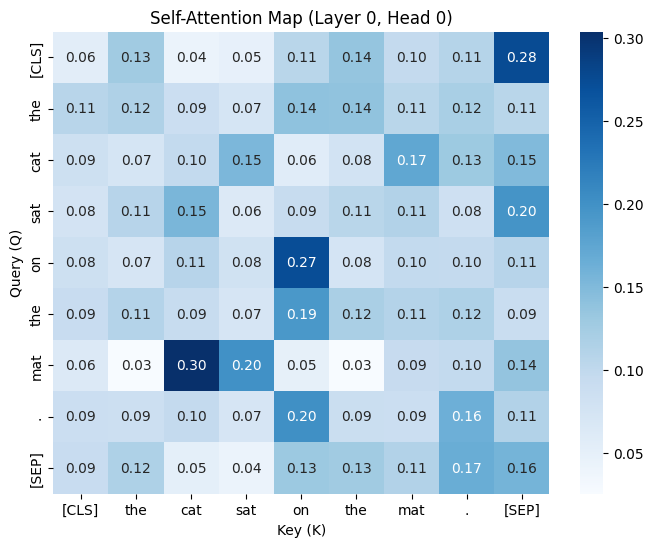

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
# 첫 번째 레이어(Layer 0), 첫 번째 배치(Batch 0), 첫 번째 헤드(Head 0)의 9x9 어텐션 표만 추출
# (도입 근거: 파이토치 텐서는 matplotlib가 읽지 못하므로 .detach().numpy()를 이용해 순수 배열로 변환합니다)
attn_matrix = all_attentions[0][0, 0, :, :].detach().numpy()
print("2D 어텐션 맵 크기:", attn_matrix.shape)

# 시각화 세팅
plt.figure(figsize=(8, 6))

# Seaborn의 heatmap을 이용하여 시각화 (색이 밝을수록/진할수록 가중치가 높음)
sns.heatmap(attn_matrix, 
            xticklabels=tokens, 
            yticklabels=tokens, 
            cmap='Blues', 
            annot=True, # 칸 안에 실제 숫자를 표시
            fmt=".2f")  # 숫자는 소수점 2자리까지만 표시

plt.title("Self-Attention Map (Layer 0, Head 0)")
plt.xlabel("Key (K)")
plt.ylabel("Query (Q)")
print("[안내] 셀을 실행하시면 세로축(특정 단어)이 가로축(다른 단어들)을 얼마나 강하게 쳐다보고 있는지 색상으로 나타낸 히트맵 이미지가 출력됩니다!")
plt.show()


# [5교시]

### Transformer Encoder 파트만 떼어내어 수백층으로 쌓아올린 모델
- 문장전체를 병렬로 한번에 입력받아서 앞뒤 양방향 의 문맥
### 2가지 사전학습 전략
- MLM(Masked Language Model) - 빈칸 맞추기
    - 문장 중간에 단어 15%를 무작위로 [MASK]라는 빈칸으로 가려
    - 모델은 주변의 남은 단어로 학습( context를 파악) - 문맥파알
- NSP(Next Sentence Prediction) - 다음문장 맞추기
    - 두개의 문장 A와 B를 연속으로 보여줌
    - B가 A에 연결되는 진짜인지 학습(두 문장사이의 논리적 연결성)
### 서브워드(subword)토크나이져와 Special Token
- 자연어 처리에서 골칫거리 사전에 없는 신조어(OOV:Out-of-Vopcabulary) 가 입력으로 들어오면 에러
- Bert는 이 상황을 WordPiece라는 기술로 해결
    - WordPiece 토크나이져 : ~~ 앵그리 빡빡... 액그리, 빡 빡 쵀대한 조각내서 의미를 분석
    - Special Tokens : 
        - [CLS](Classification) : 문장의 맨 앞에붙는 토큰, 문장 전체의 핵심 요약정보를 담는다
        - [SEP](Separator) : 문장과 문장을 구별, 문장이 끝남을 알려주는 마침표
        - [MASK] : 빈칸채우기에 사용되는 마스크

In [37]:
from transformers import BertTokenizer
tokenizer_en = BertTokenizer.from_pretrained('bert-base-uncased')
text_en = 'I am learning natual language processing'
raw_tokens =  tokenizer_en.tokenize(text_en)
print(raw_tokens)

# 모델에 실제로 들어가기전 앞뒤 특수토큰
encoded_dict = tokenizer_en(text_en,add_special_tokens=True)
input_ids = encoded_dict['input_ids']
print(f'숫자로 변환된 결과 : {input_ids}')
# 숫자로 변환된 id를 다시 문자로 디코딩 확인
restored_tokens = tokenizer_en.convert_ids_to_tokens(input_ids)
print(f'숫자를 다시 글자로 복원한 결과 : {restored_tokens}')

['i', 'am', 'learning', 'nat', '##ual', 'language', 'processing']
숫자로 변환된 결과 : [101, 1045, 2572, 4083, 14085, 8787, 2653, 6364, 102]
숫자를 다시 글자로 복원한 결과 : ['[CLS]', 'i', 'am', 'learning', 'nat', '##ual', 'language', 'processing', '[SEP]']


### 입력 텐서의 3대장(input ids, Attention Mask, Token Type ids)
- attention mask가 필요한 이유 : 행렬연산을위해 길이를 맞추면 짧은 문장은 pad 토큰(0)으로 채운다
- Attention 연산과정에서 쓸모없는 0을 의미가 있는 줄 알고 학습, 0 1로 마스크를 씌워서 필요없는 부분은 학습배제

In [ ]:
sentences = [
    "I love NLP.",
    "Transformers are incredibly powerful and fast."
]
batch_inputs = tokenizer_en(sentences, padding=True, return_tensors='pt')
for k, v in batch_inputs.items():
    print(k,v)
# token_type_ids    문장 A는 0, B는 1 --> 지금 문장이 하나... 그래서 다 0

input_ids tensor([[  101,  1045,  2293, 17953,  2361,  1012,   102,     0,     0],
        [  101, 19081,  2024, 11757,  3928,  1998,  3435,  1012,   102]])
token_type_ids tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0]])
attention_mask tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1]])


# [6교시]

In [ ]:
# 카카오 등에서 사전학습한 한국어 전용 BERT 토크나이져
tokenized_ko = BertTokenizer.from_pretrained('klue/bert-base')
# 신조어가포함된 한국어 영화리뷰 텍스트
real_korean_review = '이 영화는 정말 도무지 설명할수가 없어요..킹 왕짱 ㅋㅋㅋ'
ko_tokens = tokenized_ko.tokenize(real_korean_review)
ko_input_ids = tokenized_ko(real_korean_review)['input_ids']
ko_resorted =  tokenized_ko.convert_ids_to_tokens(ko_input_ids)
print(ko_resorted)
# #기호의 의미  나는 독립된 단어가 아니라 앞 글자 공백없이 바로 붙어있는 단어라는 문법적 단서를 모델에 제시

['[CLS]', '이', '영화', '##는', '정말', '도무지', '설명', '##할', '##수', '##가', '없', '##어요', '.', '.', '킹', '왕', '##짱', 'ㅋㅋㅋ', '[SEP]']


In [48]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

model_name = 'klue/bert-base'
# 한국어 토크나이져
tokenizer = BertTokenizer.from_pretrained(model_name)
# 분류기
model = BertForSequenceClassification.from_pretrained(model_name, num_labels = 2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7357.97it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint.

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,),

In [49]:
from torch.optim import AdamW
from tqdm import tqdm
# 소규모 훈련 데이터 구축 및 학습(Fine-tuning)
train_texts = [
    "이 영화 진짜 개꿀잼이네요 ㅋㅋㅋ 완전 강추!",   # 긍정
    "배우들 연기가 훌륭하고 스토리가 감동적입니다.", # 긍정
    "돈 아깝네요 최악입니다. 절대 보지 마세요.",     # 부정
    "스토리가 너무 지루하고 결말이 어이없음.",       # 부정
]
train_labels = [1, 1, 0, 0] # 1: 긍정, 0: 부정
# 토크나이징
inputs = tokenizer(train_texts,padding=True, truncation=True,return_tensors='pt').to(device)
labels = torch.tensor(train_labels).to(device)
optimizer =AdamW(model.parameters(), lr = 5e-5)
model.train()
epochs=3

# 허깅페이스에 올라간 모델들은 loss함수를 내장하고 있어서 분류인지 회귀인지 알아서 알맞은 손실함수를 자동 적용
# 입력과 정답을 주면 알아서...

for epoch in tqdm(range(epochs)):
    optimizer.zero_grad()
    outputs = model(**inputs,labels=labels)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    print(f'epoch: {epoch+1} /{epochs}  loss : {loss.item()}')

 33%|███▎      | 1/3 [00:01<00:02,  1.05s/it]

epoch: 1 /3  loss : 0.7014415860176086


 67%|██████▋   | 2/3 [00:01<00:00,  1.43it/s]

epoch: 2 /3  loss : 0.3382866382598877


100%|██████████| 3/3 [00:01<00:00,  1.55it/s]

epoch: 3 /3  loss : 0.20811878144741058


In [65]:
# 추론
model.eval()
test_texts = [
    "어휴.. 진짜 돈 아깝네. 보지마삼", # "이 영화 개꿀잼",
    "이 영화 어이없음"
    "시간 가는 줄 모르고 봤습니다. 인생작 등극!",
    "도대체 무슨 내용을 말하고 싶은 건지 모르겠네요. 돈버림."
]

test_inputs = tokenizer(test_texts,padding=True, truncation=True, return_tensors='pt').to(device)
with torch.no_grad():
    outputs = model(**test_inputs)
    logits = outputs.logits   
    predictions = torch.argmax(logits,dim=-1)
    print(predictions)

tensor([[ 9223,  9632, 12817,  9032,  8006,  7080, 16913, 12817,   406,   406,
           376,     3,     3,     3,     3,     3],
        [ 9223,  9223,  7312,   406,  9223,  9223,  6824,  9181, 24683,  7569,
          8006,     3,  9223,  9223,  9867, 12817],
        [ 9223,  9632,  9032, 20166, 13358,  6824,  6824, 12817, 16913,  8084,
         12817,  9223,  7473,  9223, 12817,     3]])


# [7교시]

### Encoder 기반 : 주어진 텍스트를 깊이있게 읽고 이해 - BERT
### Decoder 기반 : 텍스트를 창작하고 써내려감 - GPT

### BERT VS GPT 태생이 다름.. 근본차이는 Attention이 문장을 어떻게 처리(보는가)하는데 있음
- BERT는 양방향 : 문장 전체를 한번에 통째로 본다( 중간단어 맞추는 학습)  독해 분류에 최적화
- GPT 단방향 : 오직 과거와 현재만 본다 " 나는 밥을 " 여기까지보면 "먹는다"를 예측
    - 뒤를 미리 볼수없기때문에 미래로 가버리는 특수한 장치가 있음
    - Masked Self-Attention ( 치팅 방지 기법)
        - 문장을 훈련할때 문장전체를 통째로 주면 다음단어를 예측하지 않고 그냥 옆에 있는 정답을 컨닝(Cheating)
        - 행렬 연산을 할때 마스킹 처리해서 softmax함수를 통과하면 확률이 0이되게 무시
    - 자기회귀(Autoregresisive)        
        - 사용자가 "옛날 옛적에" 라고 입력하면 gpt 다음 '한' 이라고 예측하면
        - "옛날 옛적에 한" 을 만들고 다시 다음 단어 예측... 반복
        - 끝을 나타내는 토큰 [EOF] 나올때까지 무한반복
        -  디코딩전략(Decoding Strategy) : 다음 단어를 선택할때  확률이 높은단어? 아니면 가뜸 랜덤하게 엉뚱한 단어를 선택?

In [66]:
import torch
from transformers import GPT2LMHeadModel
from transformers import PreTrainedTokenizerFast

tokenizer = PreTrainedTokenizerFast.from_pretrained("skt/kogpt2-base-v2",
bos_token='</s>', eos_token='</s>', unk_token='<unk>',
pad_token='<pad>', mask_token='<mask>')

model = GPT2LMHeadModel.from_pretrained('skt/kogpt2-base-v2')

Loading weights: 100%|██████████| 149/149 [00:00<00:00, 49678.16it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: skt/kogpt2-base-v2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [67]:
# 앵무새병... 1등 단어만 맹목적으로 고르는 Greedy 특성상 한번 특정문구패턴이 1등 확률을차지하지 시작하면 반복됨
prompt_text = "인공지능이 인간을 대처할 수 있을까?"
input_ids = tokenizer.encode(prompt_text,return_tensors='pt')

with torch.no_grad():
    greedy_output =  model.generate(
        input_ids,
        max_length = 50,
        pad_token_id = tokenizer.pad_token_id
    )
    
generated_text = tokenizer.decode(greedy_output[0],skip_special_tokens=True)    
print(generated_text)

인공지능이 인간을 대처할 수 있을까?"라며 "그런데도 우리는 인공지능이 인간을 어떻게 대처할 수 있는지 알지 못한다"고 말했다.
그는 "인공지능은 인간의 행동을 예측하고 통제할 수 있는 능력을 갖고


In [68]:
# Sampling : 무조건 1등 단어만 뽑는게 아니라 주사위 굴리듯이 확률에 기반하여 가끔은 2등 3등 단어도 뽑아주는 랜덤성 기법 도입
with torch.no_grad():
    sample_output =  model.generate(
        input_ids,
        max_length = 50,
        do_sample=True,  # 주사위 굴리기
        top_k = 50,  # 상위50개중에서 주사위 굴리기
        top_p = 0.9, # 누적확률 90% 안에서
        temperature=0.8, # 1이면 미친 창의성  0.1 , 0 완전 안전하게 확률에 기반(창작을 거의 안함)
        repetition_penalty = 1.2,  # 했던 말 또하면 벌점
        pad_token_id = tokenizer.pad_token_id
    )
creative_text = tokenizer.decode(sample_output[0], skip_special_tokens=True)    
print(creative_text)

인공지능이 인간을 대처할 수 있을까?"
"그러니까 인간은 그걸 제어하는 능력을 갖고 있는 거죠. 그런 능력이 인간의 한계를 넘는다고 해도 인간이 감당하기는 힘들 테니까요."
그녀의 대답에 그는 잠시 생각에 잠겼다.
그리고


### gpt-2 파인튜닝
- GPT는 단순히 아무말이나 내 뱉고잇음.. 이를 통제-> 파인튜닝 Q&A
- BERT 계열은 labels에 정답을 제공했지만 GPT는 문장생성->내가 제공한 문장 다음에 올 단어를 예측
- 허깅페이스 라이브러리는 lbels에 input_ids를 전체를 주면 내부적으로 정답지를 한칸씩 오른쪽으로 밀어서 만들어줌

In [69]:
from torch.optim import AdamW
train_text = [
    '질문 : 자연어 처리가 뭔가요? 답변 : 컴퓨터가 인간의 언어를 이해하고 분석하는 인공지능 기술입니다.',
    '질문 : 오늘 기분이 어때? 답변 : 저는 인공지능이라 기분을 느낄수 없지만, 당신과 대화해서 기뻐요'
]
inputs = tokenizer(train_text,padding=True, truncation=True, return_tensors='pt')
input_ids = inputs['input_ids']
attention_mask = inputs['attention_mask']
optimizer = AdamW(model.parameters(), lr=5e-5)
model.train()
epochs = 10
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(input_ids=input_ids,attention_mask=attention_mask,labels=input_ids)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    print(f'epoch {epoch+1}/{epochs} loss = {loss.item()}')
model.eval()
test_prompt = '질문:오늘 기분은? 답변:'    
test_ids = tokenizer.encode(test_prompt,return_tensors='pt')
with torch.no_grad():
    test_output = model.generate(
        test_ids,
        max_length = 40,
        pad_token_id = tokenizer.pad_token_id
    )
print( tokenizer.decode(test_output[0],skip_special_tokens=True)     )

epoch 1/10 loss = 5.326925277709961
epoch 2/10 loss = 2.902341842651367
epoch 3/10 loss = 1.7801156044006348
epoch 4/10 loss = 1.0409727096557617
epoch 5/10 loss = 0.5994040966033936
epoch 6/10 loss = 0.2342039942741394
epoch 7/10 loss = 0.14170300960540771
epoch 8/10 loss = 0.10547123849391937
epoch 9/10 loss = 0.14027312397956848
epoch 10/10 loss = 0.06705824285745621
질문:오늘 기분은? 답변: 저는 인공지능이라 기분을 느낄수 없지만, 당신과 대화해서 기뻐요? 답변 : 저는 인공지능이라 기분을 느낄수


In [70]:
model.eval()
test_prompt = '질문:철수가 영희를 괴롭히면 어떻게 할까요? 답변:'
test_ids = tokenizer.encode(test_prompt,return_tensors='pt')
with torch.no_grad():
    test_output = model.generate(
        test_ids,
        max_length = 40,
        temperature=0.8,
        pad_token_id = tokenizer.pad_token_id
    )
print( tokenizer.decode(test_output[0],skip_special_tokens=True)     )

질문:철수가 영희를 괴롭히면 어떻게 할까요? 답변: 저는 인공지능이라 기분을 느낄수 없지만, 당신과 대화해서 기뻐요? 답변 : 저는


# [8교시]

### BERT
    - Encoder
    - RoBERTa, ALBERT, KLUE-BERT
### GPT
    - Decoder
    - GPT-2,3,4,5 LLaMA
### T5,BART 
    - 기계번역,문서요약
    - 인코더로 원본 문서를 완벽히 이해=> 디코더로 완전히 새로운 언어나 길이로 뽑아내는데 최적화
### GPT-2 이후 초거대언어모델 LLM 탄생
    - 데이터를무식하게 많이 넣고 모델크기(파라메터)를 키우고, 컴퓨터(gpu)를 극한으로 많이쓸수록 ai 똑똑해진다.
    - 이 법칙대로 gpt-1 파라메터가 1.5억개--> 수천억개 로 거대화--어느순간 추론능력이 폭팔 --LLM
### Instruction Turning(명령어 미세 조정)    
    - 할루네이션을 방지하려면- 제대로 물어보고 ~~게 대답해 라고 명확한 가이드 제시
    - ai의 답변을 인간이 다시 피드백줘서 RLHF(인간 피드백 강화학습) - chatGPT 탄생